# Chapter 15: Моделирование последовательных данных с помощью рекуррентных неиронных сетеи 


Предыдущая глава была посвящена сверточным нейронным сетям (CNN). Мы рассмотрели функциональные блоки этой архитектуры и способы реализации глубоких CNN в PyTorch. Вы также узнали, как использовать CNN для классификации изображений. Здесь же мы познакомимся с рекуррентными нейронными сетями (RNN) и их применением в моделировании последовательных данных.\
В этой главе будут рассмотрены следующие темы:\
♦ понятие последовательных данных;\
♦ RNN для моделирования последовательностей;\
♦ долгая краткосрочная память;\
♦ усеченное обратное распространение во времени;\
♦ реализация многослойной RNN для моделирования последовательности в PyTorch;\
♦ первый проект: анализ эмоциональной окраски в наборе данных обзоров фильмов IMDb;\
♦ второй проект: моделирование языка на уровне символов с ячейками LSTM на текстовых данных из книги Жюля Верна «Таинственный остров»;\
♦ использование обрезки градиента, чтобы избежать взрыва градиентов. 

In [1]:
from IPython.display import Image
%matplotlib inline

# 15.1. Знакомство с понятием последовательных данных 



Давайте начнем обсуждение RNN с рассмотрения природы последовательных данных (sequential data), которые часто называют просто последовательностями (sequence). Мы рассмотрим уникальные свойства последовательностей, которые отличают их от других видов данных. Затем вы познакомитесь со способами представления последовательных данных и с различными категориями моделей для последовательных данных, которые основаны на входах и выходах модели. Это поможет нам исследовать связь между RNN и последовательностями. 

### 15.1.1. Моделирование последовательных данных: порядок имеет значение 

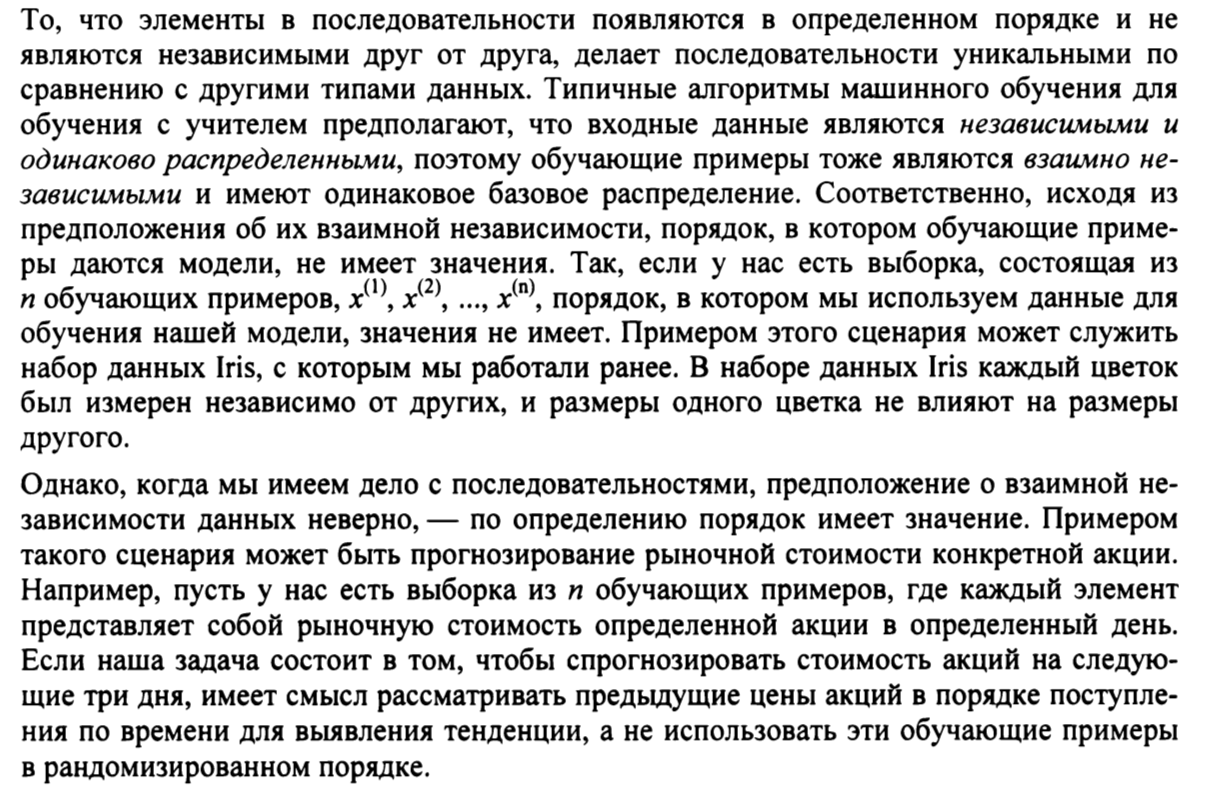

In [3]:
Image(filename='figures/текст1.png', width=700)

### 15.1.2. Данные временных рядов - особый тип последовательных данных 

Данные временных рядов - это особый тип последовательных данных, где каждый пример связан с измерением времени. В данных временных рядов выборки берутся с последовательными временными метками, и поэтому измерение времени определяет порядок точек данных. Например, данными временных рядов являются курсы акций и голосовые записи.

С другой стороны, не все последовательные данные имеют измерение времени. Например, в текстовых данных или последовательностях ДНК экземпляры упорядочены, но текст или ДНК не имеют составляющую времени. В этой главе мы сосредоточимся на примерах обработки естественного языка (Natural Language Processing, NLP) и моделирования текста, которые не являются данными временных рядов. Надо, впрочем, заметить, что RNN также можно использовать для данных временных рядов, но их рассмотрение выходит за рамки этой книги. 

### 15.1.3. Способы представления последовательностей 

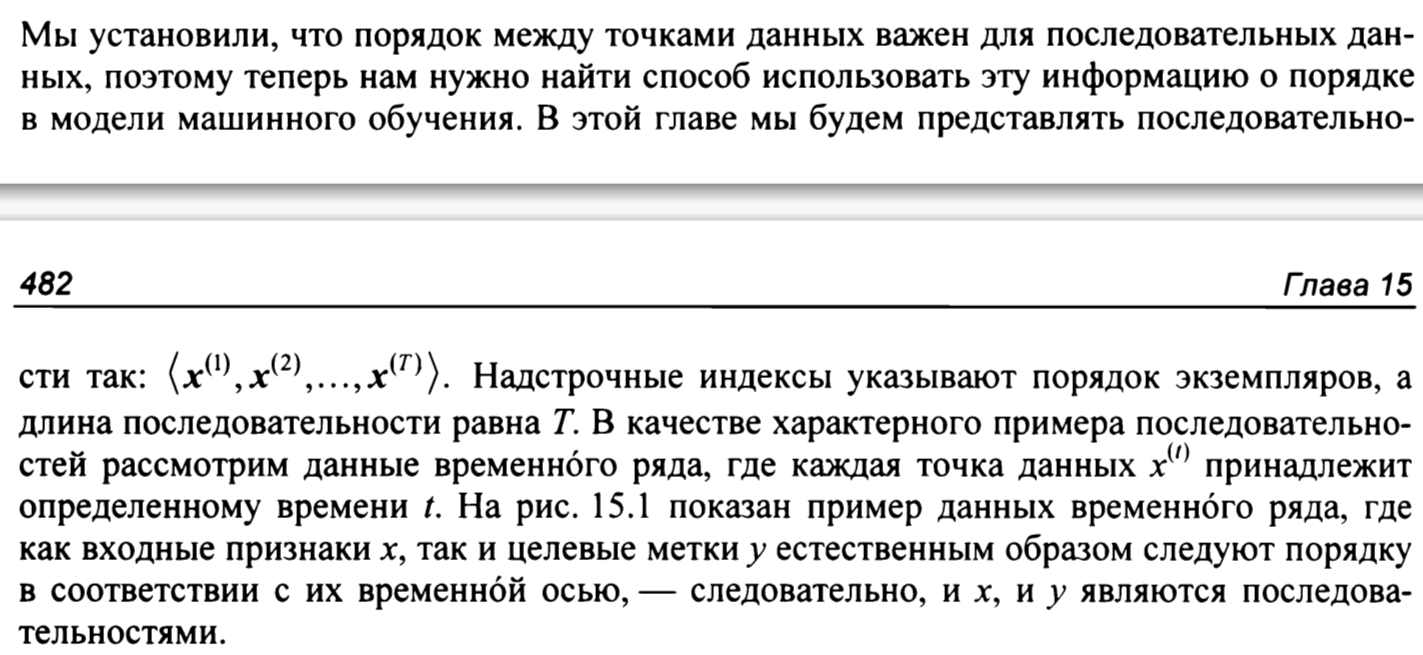

In [4]:
Image(filename='figures/текст2.png', width=700)

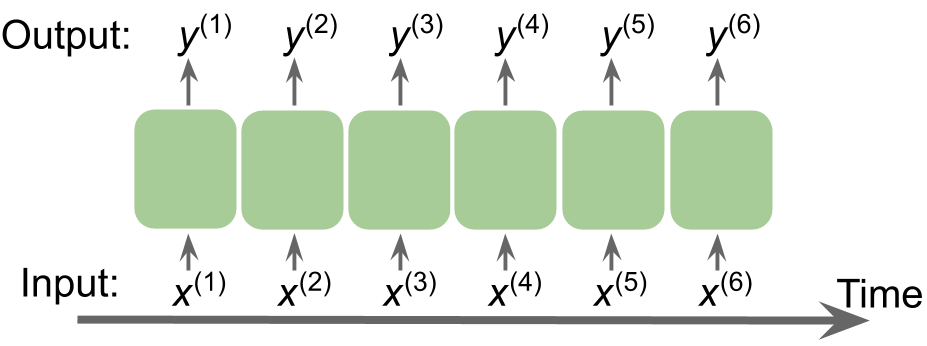

In [5]:
Image(filename='figures/15_01.png', width=500)

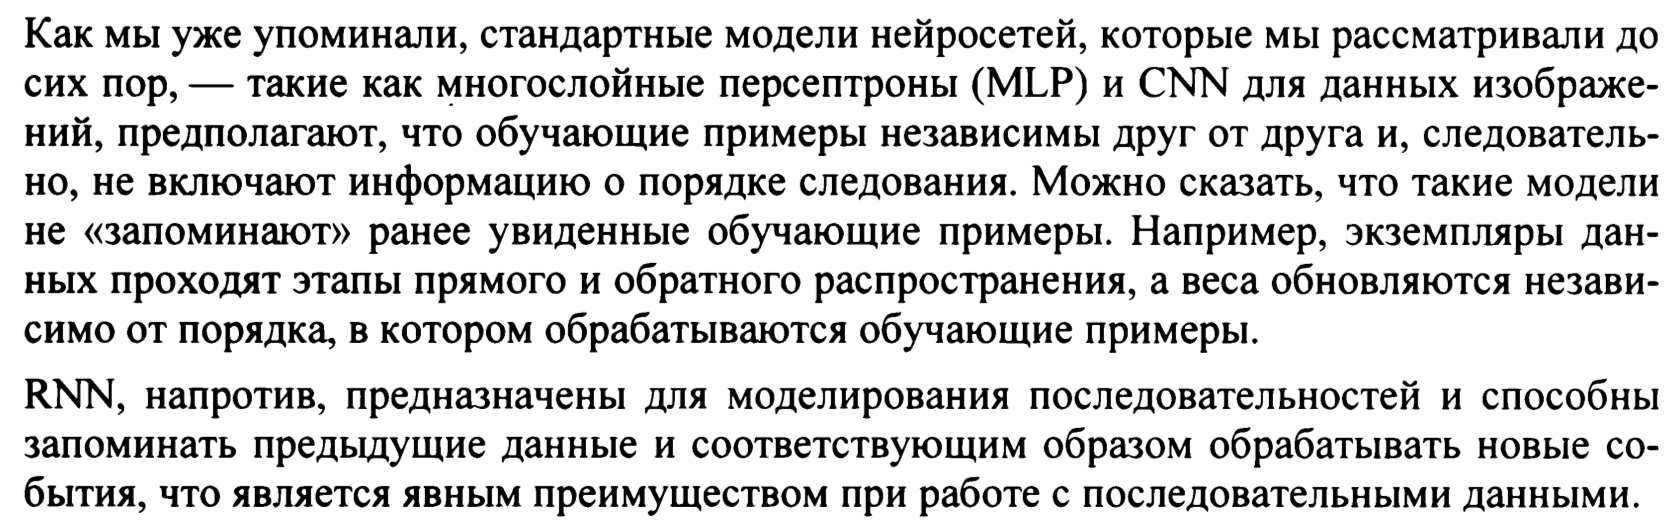

In [6]:
Image(filename='figures/текст3.png', width=700)

## 15.1.4. Различные категории моделирования последовательности 

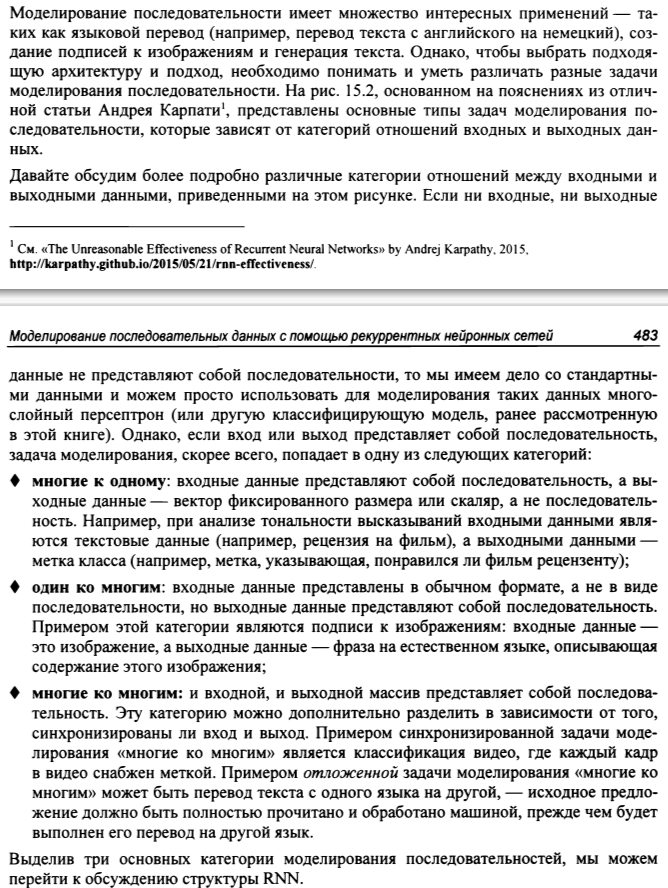

In [7]:
Image(filename='figures/текст4.png', width=700)

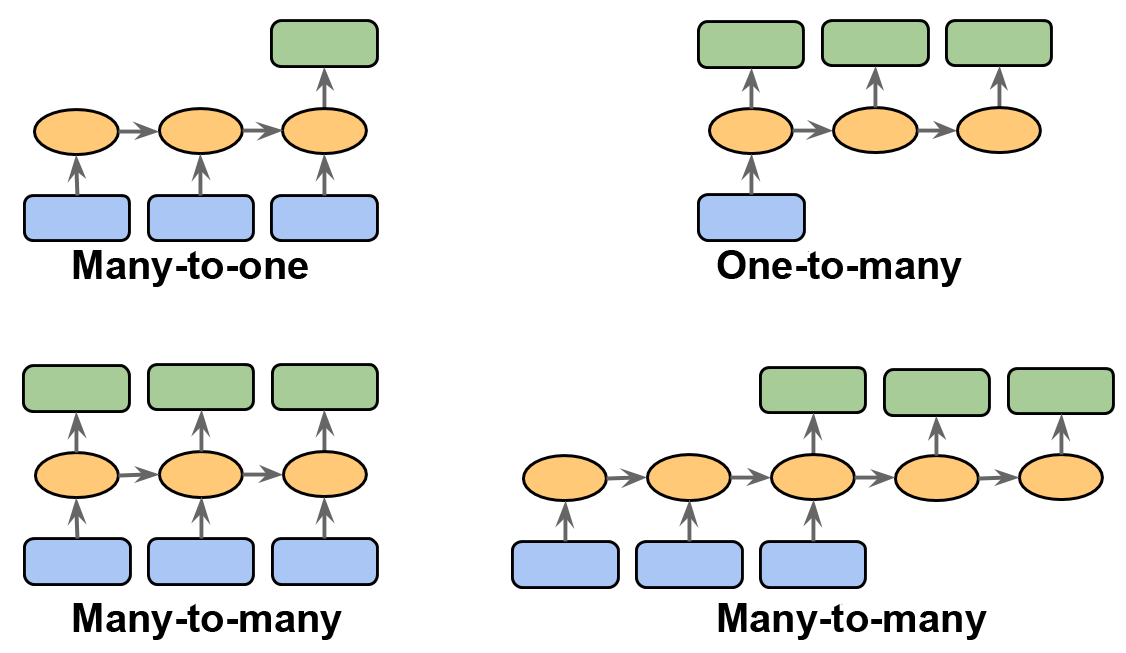

In [3]:
Image(filename='figures/15_02.png', width=500)

# RNNs for modeling sequences

## Understanding the RNN looping mechanism


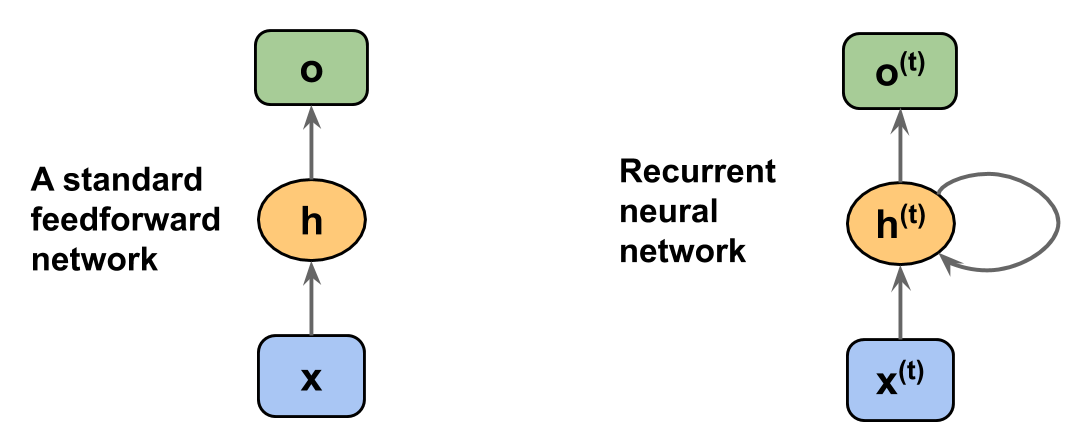

In [4]:
Image(filename='figures/15_03.png', width=500)

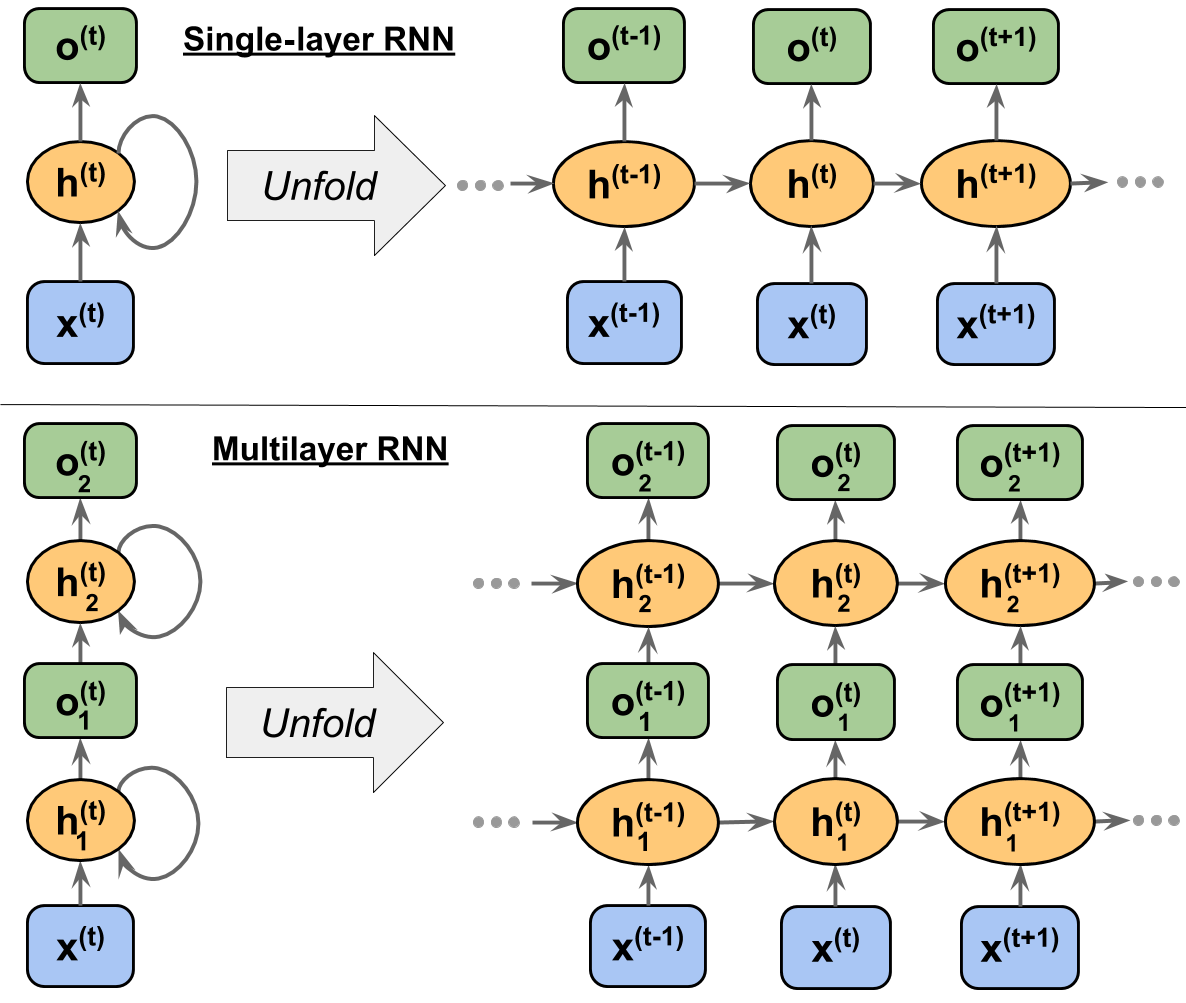

In [5]:
Image(filename='figures/15_04.png', width=500)

## Computing activations in an RNN


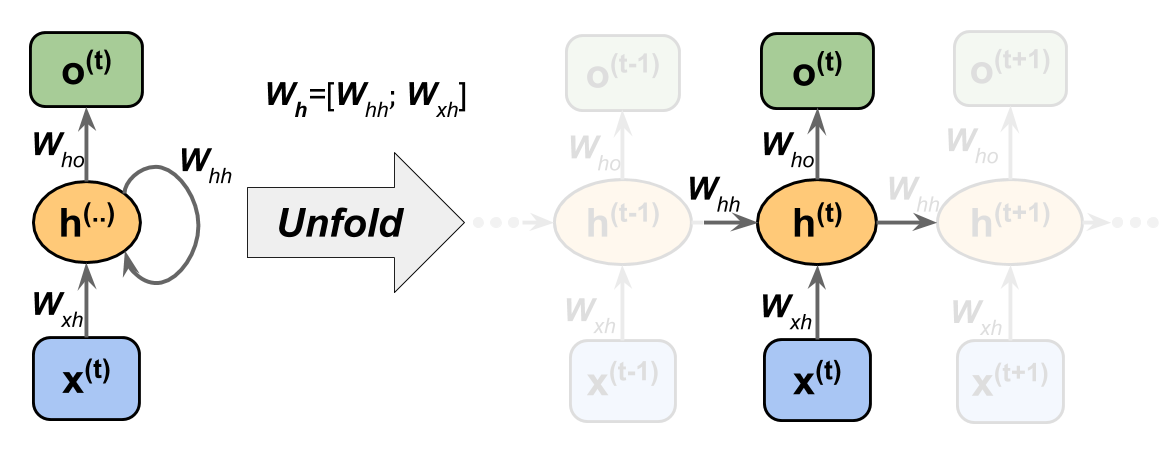

In [6]:
Image(filename='figures/15_05.png', width=500)

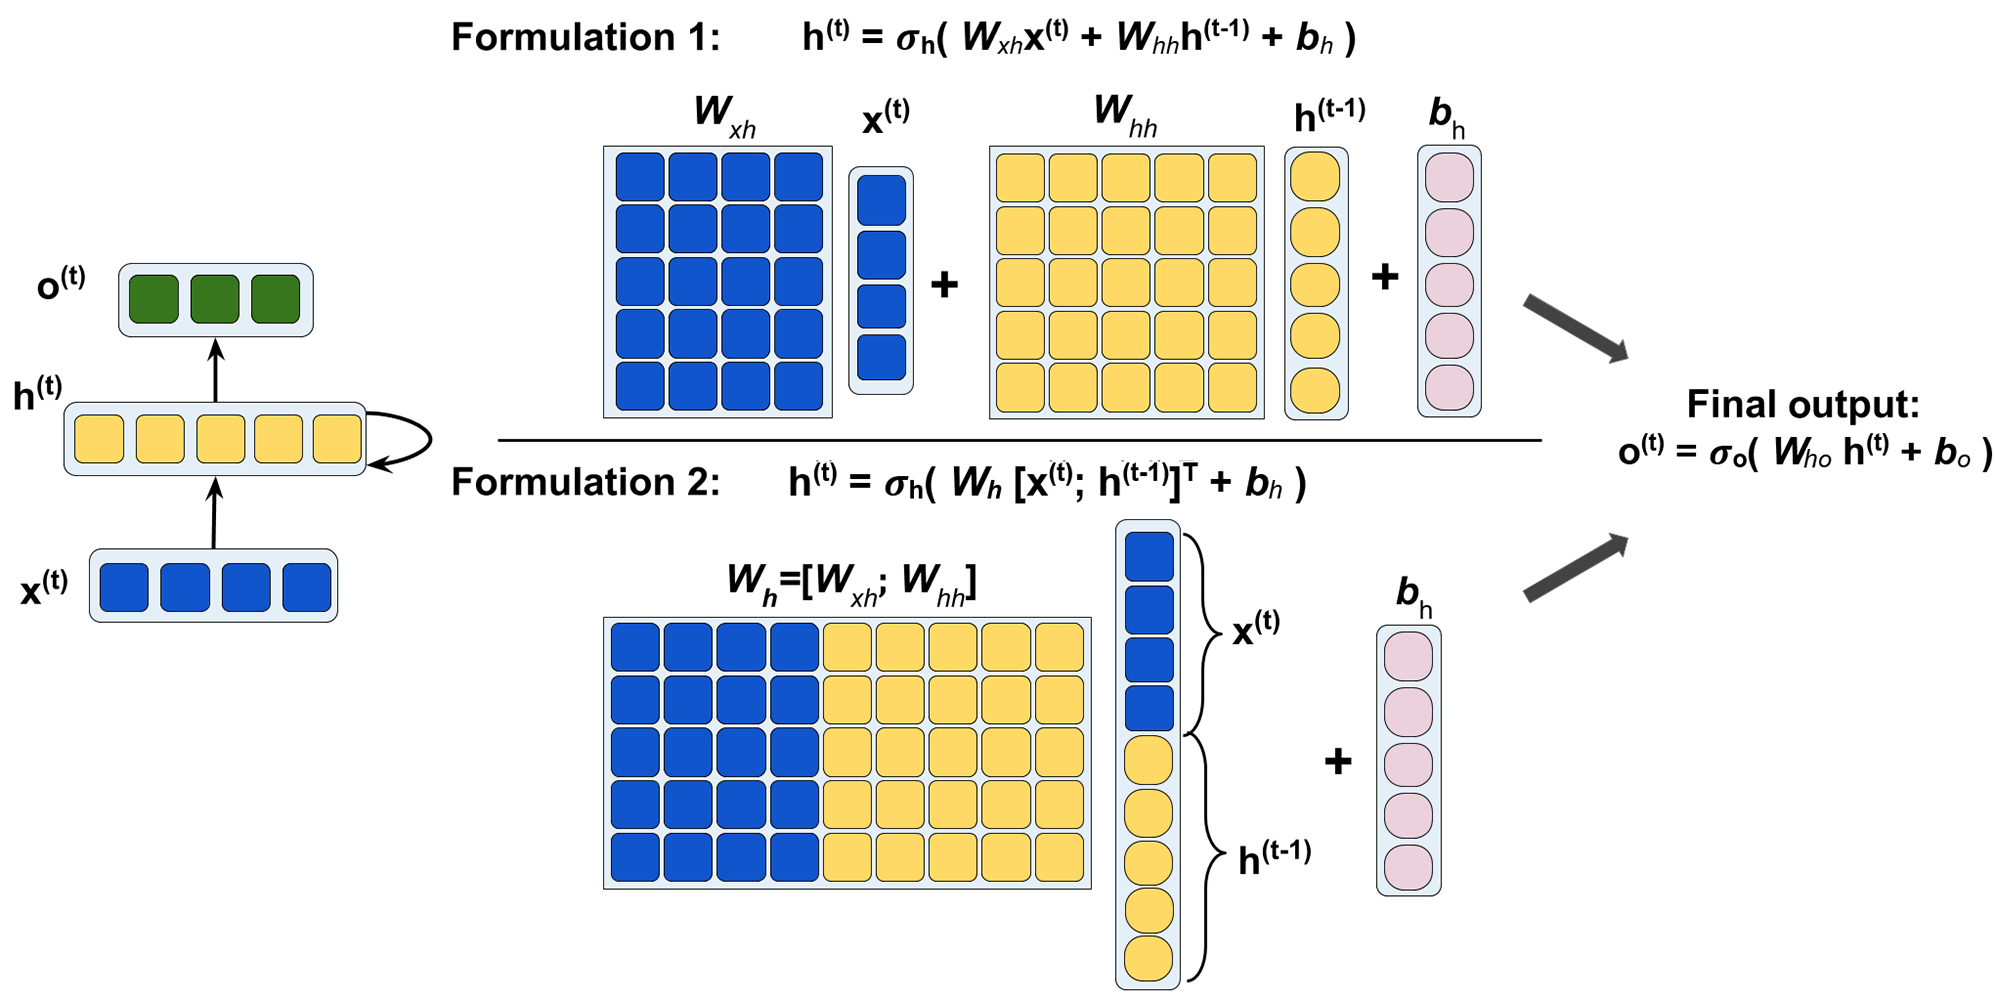

In [5]:
Image(filename='figures/15_06.png', width=700)

## Hidden-recurrence vs. output-recurrence

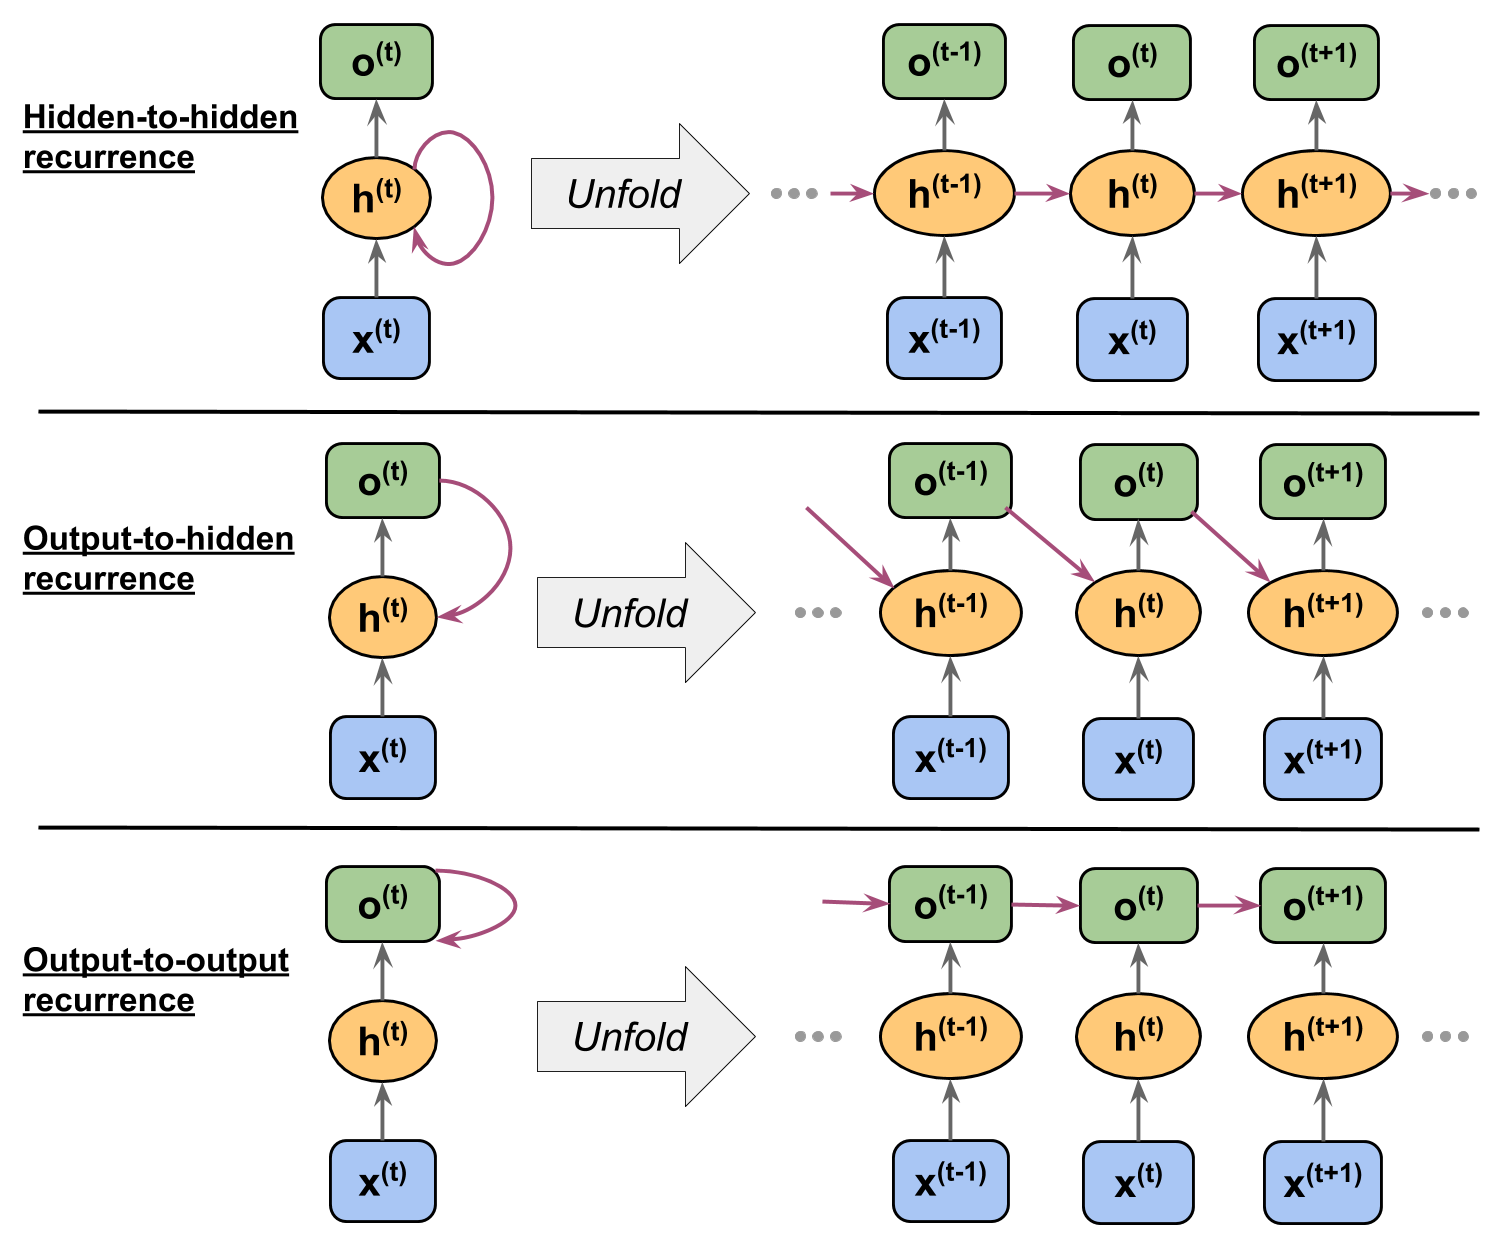

In [8]:
Image(filename='figures/15_07.png', width=500)

In [11]:
import torch
import torch.nn as nn

torch.manual_seed(1)

rnn_layer = nn.RNN(input_size=5, hidden_size=2, num_layers=1, batch_first=True) 

w_xh = rnn_layer.weight_ih_l0
w_hh = rnn_layer.weight_hh_l0
b_xh = rnn_layer.bias_ih_l0
b_hh = rnn_layer.bias_hh_l0

print('W_xh shape:', w_xh.shape)
print('W_hh shape:', w_hh.shape)
print('b_xh shape:', b_xh.shape)
print('b_hh shape:', b_hh.shape)

W_xh shape: torch.Size([2, 5])
W_hh shape: torch.Size([2, 2])
b_xh shape: torch.Size([2])
b_hh shape: torch.Size([2])


In [12]:
x_seq = torch.tensor([[1.0]*5, [2.0]*5, [3.0]*5]).float()

## output of the simple RNN:
output, hn = rnn_layer(torch.reshape(x_seq, (1, 3, 5)))

## manually computing the output:
out_man = []
for t in range(3):
    xt = torch.reshape(x_seq[t], (1, 5))
    print(f'Time step {t} =>')
    print('   Input           :', xt.numpy())
    
    ht = torch.matmul(xt, torch.transpose(w_xh, 0, 1)) + b_xh    
    print('   Hidden          :', ht.detach().numpy())
    
    if t>0:
        prev_h = out_man[t-1]
    else:
        prev_h = torch.zeros((ht.shape))

    ot = ht + torch.matmul(prev_h, torch.transpose(w_hh, 0, 1)) + b_hh
    ot = torch.tanh(ot)
    out_man.append(ot)
    print('   Output (manual) :', ot.detach().numpy())
    print('   RNN output      :', output[:, t].detach().numpy())
    print()

Time step 0 =>
   Input           : [[1. 1. 1. 1. 1.]]
   Hidden          : [[-0.4701929  0.5863904]]
   Output (manual) : [[-0.3519801   0.52525216]]
   RNN output      : [[-0.3519801   0.52525216]]

Time step 1 =>
   Input           : [[2. 2. 2. 2. 2.]]
   Hidden          : [[-0.88883156  1.2364397 ]]
   Output (manual) : [[-0.68424344  0.76074266]]
   RNN output      : [[-0.68424344  0.76074266]]

Time step 2 =>
   Input           : [[3. 3. 3. 3. 3.]]
   Hidden          : [[-1.3074701  1.886489 ]]
   Output (manual) : [[-0.8649416   0.90466356]]
   RNN output      : [[-0.8649416   0.90466356]]



## The challenges of learning long-range interactions


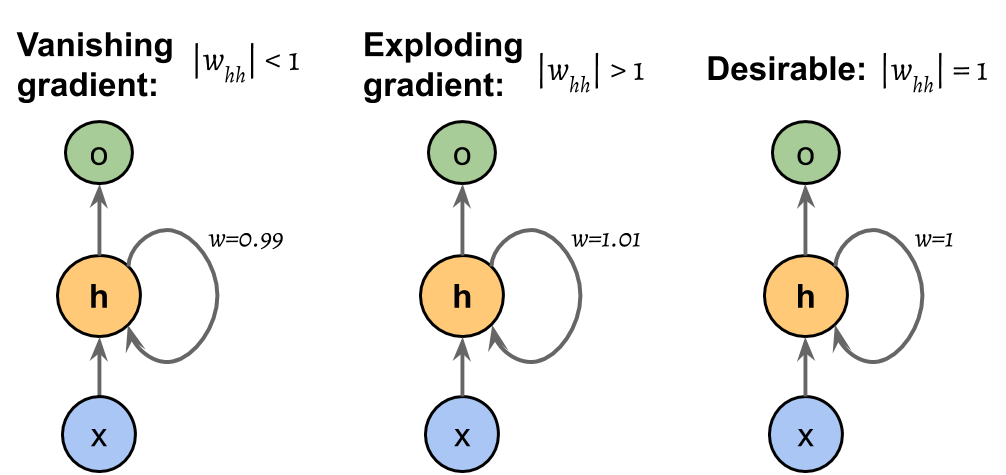

In [9]:
Image(filename='figures/15_08.png', width=500)


## Long Short-Term Memory cells 

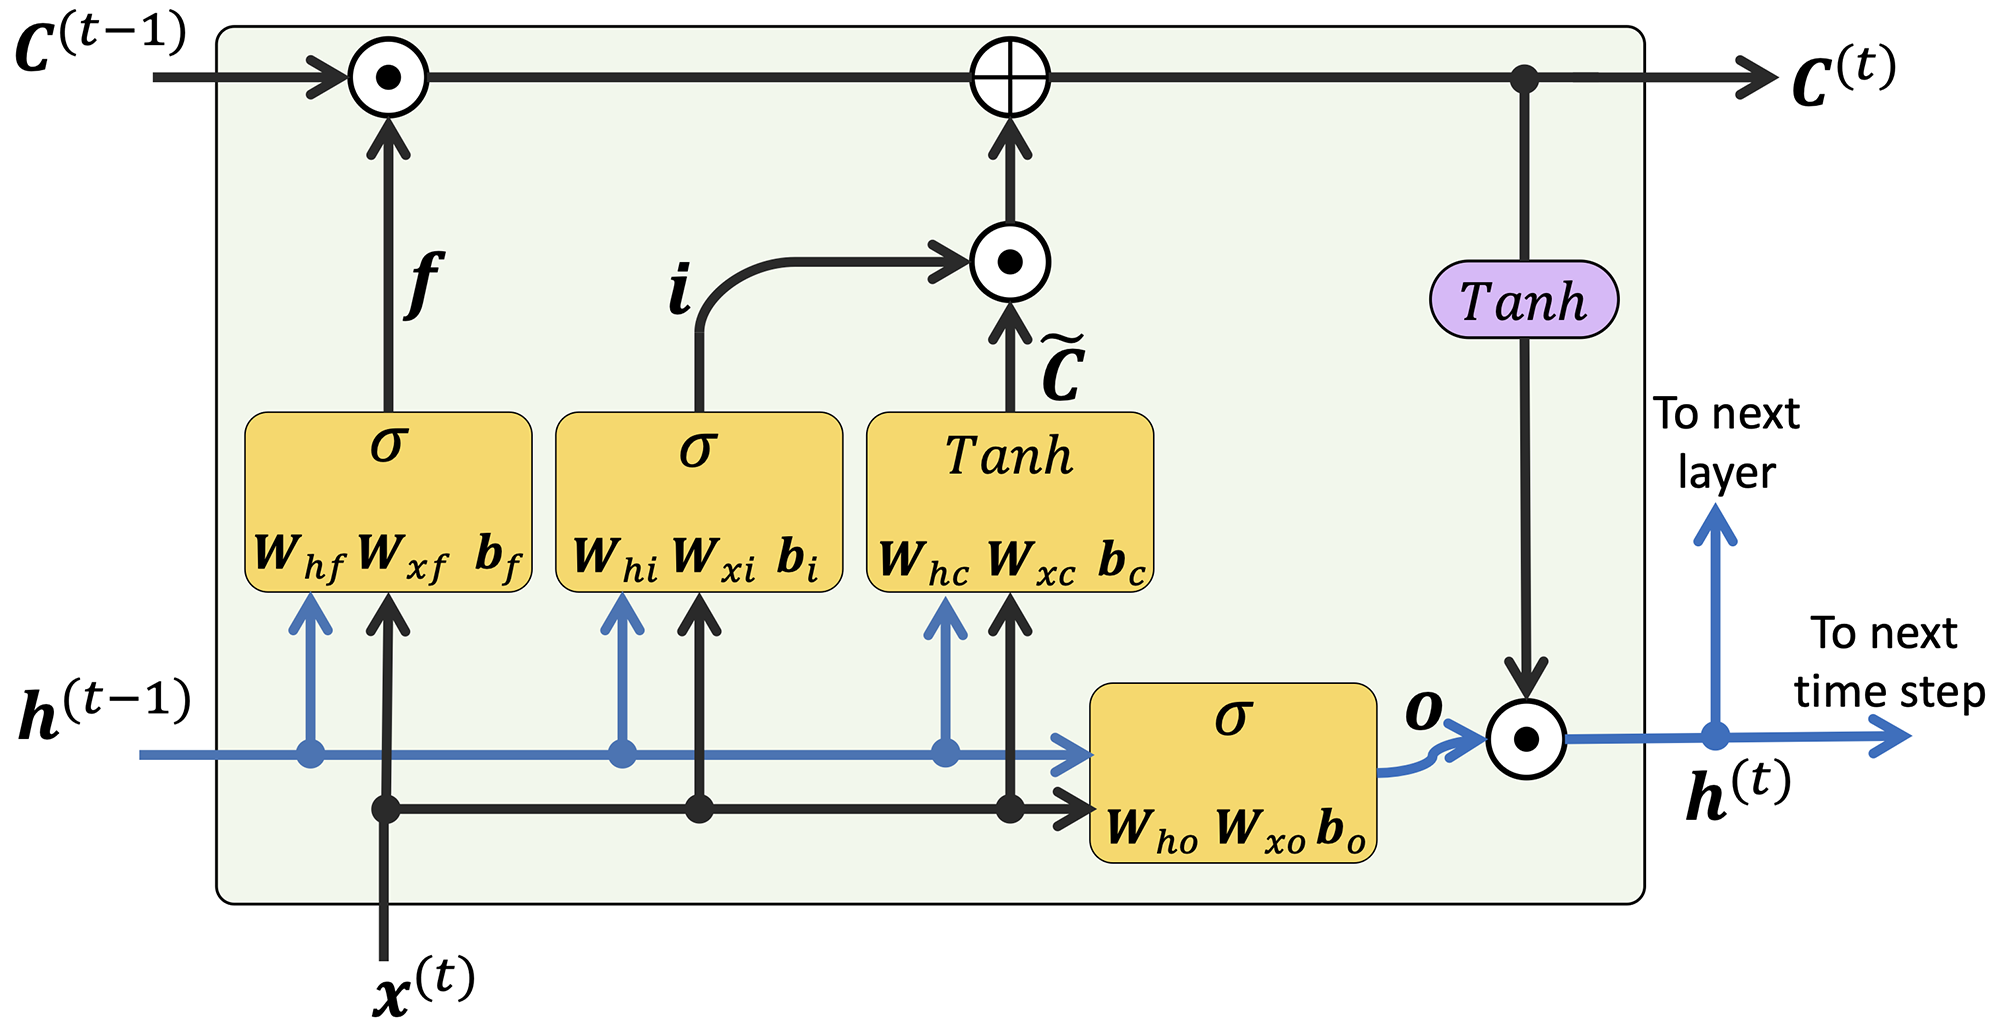

In [10]:
Image(filename='figures/15_09.png', width=500)

<br>
<br>

---



Readers may ignore the next cell.


In [15]:
! python ../.convert_notebook_to_script.py --input ch15_part1.ipynb --output ch15_part1.py

[NbConvertApp] Converting notebook ch15_part1.ipynb to script
[NbConvertApp] Writing 3919 bytes to ch15_part1.py
